# 02. Baseline Model

В этом ноутбуке строится baseline-модель для задачи прогнозирования
оттока клиентов.

В качестве baseline используется Logistic Regression со стандартным
порогом классификации `threshold = 0.5`.

Цель этапа — получить исходный уровень качества, с которым в дальнейшем
будут сравниваться более сложные модели и оптимизированные конфигурации.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

## 1. Подготовка данных

### 1.1 Загрузка данных

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Обработка TotalCharges

Признак `TotalCharges` в исходном датасете хранится как строковый.

Преобразуем его в числовой формат. Пустые значения относятся к клиентам
с `tenure = 0`, поэтому для них `TotalCharges` принимается равным 0.

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.loc[
    df["tenure"] == 0,
    "TotalCharges"
] = 0

In [24]:
df['TotalCharges'].dtype

dtype('float64')

### 1.3 Формирование признаков и целевой переменной

Целевая переменная `Churn` преобразуется в бинарный формат:

- `No` → 0;
- `Yes` → 1.

`customerID` исключается из признаков, поскольку является идентификатором
клиента и не несёт полезной информации для модели.

In [5]:
y = df["Churn"].map({
    "No": 0,
    "Yes" : 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)

### 1.4 Разделение данных

Данные разделяются на обучающую и тестовую выборки в соотношении 80/20.

Параметр `stratify=y` сохраняет исходное соотношение классов в обеих
выборках.

Тестовая выборка не используется при обучении preprocessing и модели.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 2. Preprocessing

Для Logistic Regression числовые признаки стандартизируются с помощью
`StandardScaler`, а категориальные признаки преобразуются в числовое
представление с помощью `OneHotEncoder`.

Все преобразования выполняются внутри `Pipeline`, поэтому параметры
preprocessing обучаются только на `X_train`.

In [8]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_24808\2015223730.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
            handle_unknown='ignore',
            drop="first"
        ),
        categorical_features
        )
    ]
)

## 3. Baseline Logistic Regression

В качестве baseline используется Logistic Regression без подбора
гиперпараметров.

Используется стандартный `C = 1` и `class_weight = None`.

Стандартный threshold равен `0.5`.

In [11]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                C=1,
                max_iter=10000
            )
        )
    ]
)

In [12]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

## 4. Предсказания

Получим два типа предсказаний:

- бинарный класс `y_pred`;
- вероятность принадлежности к классу `Churn = 1`.

In [13]:
y_pred = baseline_model.predict(X_test)

In [14]:
y_proba = baseline_model.predict_proba(X_test)[:,1]

## 5. Evaluation

### 5.1 Confusion Matrix

Confusion Matrix показывает количество правильных и ошибочных
классификаций для каждого класса.

Строки соответствуют истинным классам, столбцы — предсказанным.

In [16]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[927 108]
 [164 210]]


Для baseline-модели:

- TN = 927
- FP = 108
- FN = 164
- TP = 210

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.807
Precision: 0.660
Recall:    0.561
F1-score:  0.607


## 7. ROC-кривая и ROC-AUC

ROC-кривая показывает изменение True Positive Rate (Recall)
и False Positive Rate при изменении порога классификации.

Для построения ROC-кривой используются вероятности принадлежности
к положительному классу, полученные с помощью `predict_proba()`.

Площадь под ROC-кривой обозначается как ROC-AUC.

In [17]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

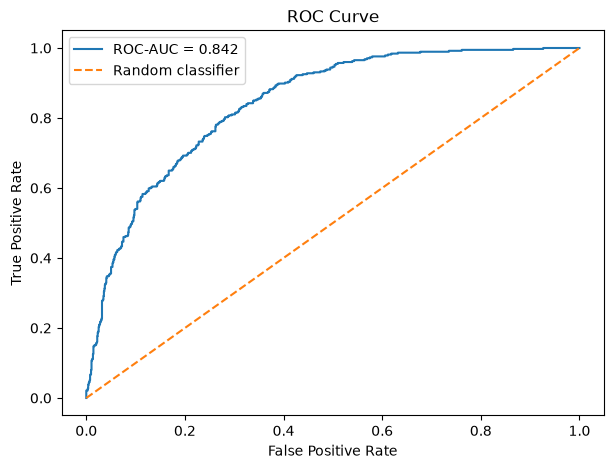

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 6. Baseline Summary

Logistic Regression в качестве baseline показала следующие результаты
на тестовой выборке:

| Metric | Value |
|---|---:|
| Accuracy | 0.807 |
| Precision | 0.660 |
| Recall | 0.561 |
| F1 | 0.607 |
| ROC-AUC | 0.842 |

Модель используется как исходная точка для дальнейшего сравнения.

В следующем этапе будут исследованы другие алгоритмы, выполнен подбор
гиперпараметров и рассмотрен выбор оптимального порога классификации.